# Predicting Headline Success: The Limits of Traditional NLP

## 1. Introduction & Objective

### Project Goal
The goal of this notebook is to build a robust predictive model to determine whether a headline will be the **"Highest CTR Performer"** within its A/B test group using **Advanced Traditional NLP techniques**.

### Context in the Project
This section serves as a **benchmark** for our team's project. While other team members explore **Generative AI (LLMs)**, this notebook rigorously tests the limits of statistical machine learning methods.
We aim to answer: *"Can we predict the best-performing headline using only linguistic features and keywords?"*

### Methodology
We employ a comprehensive pipeline:
1.  **Data Strategy:** We train on the large `Confirmatory` dataset (105k+ samples) and validate on the unseen `Holdout` dataset (22k samples).
2.  **Target Re-definition:** Instead of using the editorial `winner` column, we calculate `is_highest_ctr` to identify the objective winner based on actual performance.
3.  **Hybrid Feature Engineering:** We combine **TF-IDF vectors** (textual content) with **Handcrafted Metadata** (sentiment, readability, part-of-speech tags).
4.  **Advanced Modeling:** We compare **Logistic Regression**, **Random Forest**, and **XGBoost**.

## 2. Data Loading & Target Calculation

### Dataset Selection
We strictly follow the best practices for predictive modeling:
* **Training Set (`Confirmatory`):** This is the largest dataset available, used for training to expose the model to various linguistic patterns.
* **Test Set (`Holdout`):** This dataset has never been seen by the model during training, ensuring reliable evaluation.

### Defining the Target: `is_highest_ctr`
To remove editorial bias, we calculate the Click-Through Rate (CTR) for each headline (`clicks / impressions`) and mark the headline with the **maximum CTR** in each test group as the target (1), while others are marked as (0).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, confusion_matrix

# 1. Load the datasets
# Please ensure the file paths are correct

train_df = pd.read_csv("dataset/processed/confirmatory-packages-topic-modeling.csv")
test_df = pd.read_csv("dataset/processed/holdout-packages-topic-modeling.csv")

# 2. Define the Target Variable (Modified as per request)
def create_highest_ctr_target(df):
    # Calculate CTR if missing (clicks / impressions)
    if 'ctr' not in df.columns:
        df['ctr'] = df['clicks'] / df['impressions']
    
    # Find max CTR per test group
    df['max_ctr_per_test'] = df.groupby('clickability_test_id')['ctr'].transform('max')
    
    # Mark as 1 if it is the highest CTR, else 0
    df['is_highest_ctr'] = (df['ctr'] == df['max_ctr_per_test']).astype(int)
    return df

train_df = create_highest_ctr_target(train_df)
test_df = create_highest_ctr_target(test_df)

y_train = train_df['is_highest_ctr']
y_test = test_df['is_highest_ctr']

# 3. Check Data Shape and Balance
print(f"Training Data Shape: {train_df.shape}")
print(f"Test Data Shape: {test_df.shape}")

# Calculate the percentage of highest CTRs (approx 1 per group of ~4-5 headlines)
winner_rate = y_train.mean()
print(f"\nHighest CTR Rate in Training Set: {winner_rate:.2%}")
print(f"Imbalance Ratio: 1 Highest CTR for every {int((1-winner_rate)/winner_rate)} Others")

Training Data Shape: (105551, 51)
Test Data Shape: (22600, 51)

Highest CTR Rate in Training Set: 21.56%
Imbalance Ratio: 1 Highest CTR for every 3 Others


## 3. Feature Engineering

To give our models the best chance of success, we combine two powerful types of features.

### 3.1 Handcrafted Metadata (Linguistic Features)
These features capture the **style and structure** of the headline.
* **Sentiment:** Is the headline positive or negative? (VADER scores)
* **Readability:** Is it easy to read? (Flesch-Kincaid score)
* **Structure:** Does it start with a question? How many nouns does it have?

We **scale** these numerical features so that models like Logistic Regression treat them equally.

In [2]:
# List of handcrafted numerical features
numeric_features = [
    'headline_num_persons', 'headline_num_orgs', 'headline_num_gpes',
    'num_chars', 'num_tokens', 'avg_token_len',
    'num_nouns', 'num_verbs', 'num_adjs', 'num_advs',
    'neg', 'neu', 'pos', 'compound',  
    'read_flesch', 'read_coleman',    
    'specificity_tfidf',
    'starts_with_verb', 'starts_with_pronoun', 'starts_with_number',
    'headline_imperative_verb', 'headline_has_curiosity_word'
]

# 1. Handle Missing Values (Fill with 0)
X_train_meta = train_df[numeric_features].fillna(0).astype(float)
X_test_meta = test_df[numeric_features].fillna(0).astype(float)

# 2. Scale Features (Standardization: Mean=0, Std=1)
scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)
X_test_meta_scaled = scaler.transform(X_test_meta)

print("Handcrafted features processed and scaled.")

Handcrafted features processed and scaled.


### 3.2 Textual Features (TF-IDF)
While metadata captures structure, we also need to capture the **content**.
We use **TF-IDF (Term Frequency-Inverse Document Frequency)** to vectorize the headline text.
* **N-grams:** We use Unigrams (single words) and Bigrams (two-word phrases) to capture context like "Climate Change".
* **Vocabulary:** We limit to the top 5,000 most important features to avoid noise.

In [3]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words = 'english',
    max_features = 5000,   
    ngram_range = (1, 2),  
    min_df=5             
)

# Fit on Training Data and Transform both Train and Test
X_train_tfidf = tfidf.fit_transform(train_df['headline'].fillna(''))
X_test_tfidf = tfidf.transform(test_df['headline'].fillna(''))

print(f"TF-IDF Matrix Shape: {X_train_tfidf.shape}")

TF-IDF Matrix Shape: (105551, 5000)


### 3.3 Feature Combination (Stacking)
Now, we fuse the **Metadata Matrix** and the **TF-IDF Matrix** into a single dataset. This gives our models a holistic view of each headline.

In [4]:
# Horizontally stack the sparse TF-IDF matrix and the dense metadata matrix
X_train_combined = hstack([X_train_tfidf, X_train_meta_scaled])
X_test_combined = hstack([X_test_tfidf, X_test_meta_scaled])

print(f"Final Training Feature Matrix: {X_train_combined.shape}")

Final Training Feature Matrix: (105551, 5022)


## 4. Model Training & Benchmarking

### Model Selection
We benchmark three different algorithms:
1.  **Logistic Regression:** A linear baseline model.
2.  **Random Forest:** Captures non-linear interactions.
3.  **XGBoost:** Gradient boosting machine, state-of-the-art for tabular data.

### Handling Class Imbalance
Even with `is_highest_ctr`, only about 20-25% of headlines are winners (since 1 wins out of 4-5 options).
We calculate the exact ratio and apply **Class Weighting** to ensure the models pay attention to the winners.

In [6]:
# Calculate imbalance ratio for XGBoost scale_pos_weight
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

# Define the models with Class Weighting
models = {
    "Logistic Regression": LogisticRegression(
        max_iter = 1000, 
        random_state = 42, 
        class_weight = 'balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators = 100, 
        max_depth = 15, 
        random_state = 42, 
        class_weight = 'balanced'
    ),
    "XGBoost": XGBClassifier(
        n_estimators = 100,
        learning_rate = 0.1,
        max_depth = 6,
        eval_metric = 'logloss',
        scale_pos_weight = scale_pos_weight, 
        random_state = 42
    )
}

results = []

print("Training models... This may take a few minutes.")
print("-" * 60)

for name, model in models.items():
    # Train the model
    model.fit(X_train_combined, y_train)
    
    # Predict on the Holdout Set
    y_pred = model.predict(X_test_combined)
    y_prob = model.predict_proba(X_test_combined)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.5
    
    # Count predicted winners
    pred_winners = np.sum(y_pred)
    
    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "ROC-AUC": roc,
        "Predicted_Winners": pred_winners,
        "Model_Obj": model 
    })
    print(f"[{name}] ROC-AUC: {roc:.4f} | F1: {f1:.4f} | Pred Winners: {pred_winners}")

print("-" * 60)
print("Training Complete.")

Calculated scale_pos_weight for XGBoost: 3.64
Training models... This may take a few minutes.
------------------------------------------------------------
[Logistic Regression] ROC-AUC: 0.5518 | F1: 0.3295 | Pred Winners: 10473
[Random Forest] ROC-AUC: 0.5432 | F1: 0.3269 | Pred Winners: 10811
[XGBoost] ROC-AUC: 0.5416 | F1: 0.3389 | Pred Winners: 12856
------------------------------------------------------------
Training Complete.


## 5. Evaluation & Results

### Performance Comparison
We compare the models based on **ROC-AUC** (Area Under the Curve).
* **ROC-AUC** is robust for imbalanced datasets. A score of **0.5** indicates random guessing performance.


=== Final Model Leaderboard (Target: Highest CTR) ===


,Model,Accuracy,F1-Score,ROC-AUC,Predicted_Winners
0,Logistic Regression,0.544735,0.329488,0.551773,10473
1,Random Forest,0.532876,0.326851,0.543184,10811
2,XGBoost,0.481416,0.338899,0.541592,12856


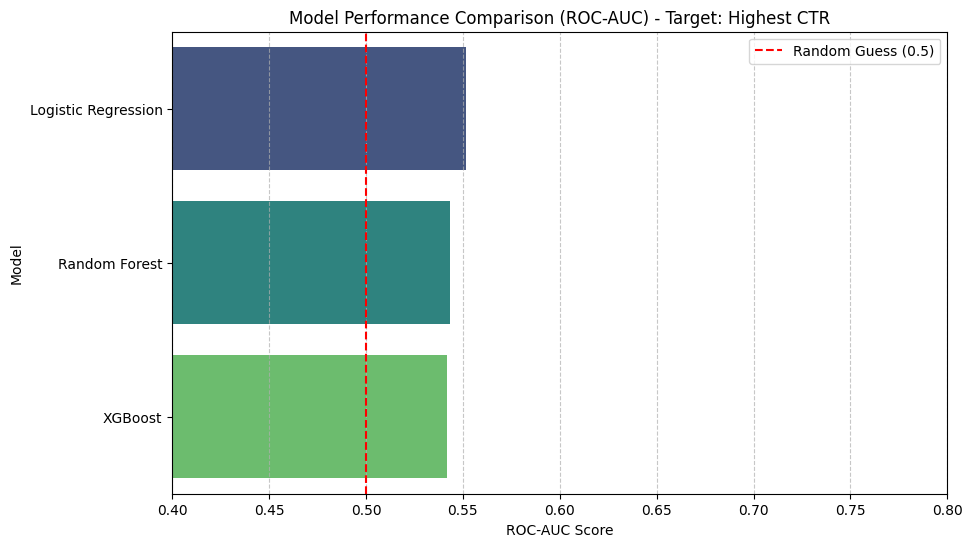

In [10]:
# Create a DataFrame for easy comparison
results_df = pd.DataFrame(results).drop(columns=['Model_Obj']).sort_values(by="ROC-AUC", ascending=False)
print("\n=== Final Model Leaderboard (Target: Highest CTR) ===")
display(results_df)

# Visualize the ROC-AUC Scores
plt.figure(figsize=(10, 6))
sns.barplot(x = "ROC-AUC", y = "Model", data = results_df, hue = "Model", palette = "viridis", legend = False)
plt.title("Model Performance Comparison (ROC-AUC) - Target: Highest CTR")
plt.xlabel("ROC-AUC Score")
plt.xlim(0.4, 0.8) 
plt.axvline(0.5, color = 'red', linestyle = '--', label = 'Random Guess (0.5)')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 6. Feature Importance Analysis

### What drives the "Highest CTR"?
We analyze the inner workings of our best-performing model to understand **which features matter most**.
This helps us understand if specific words or sentiments actually drive higher clicks.

Analyzing Feature Importance for: Logistic Regression


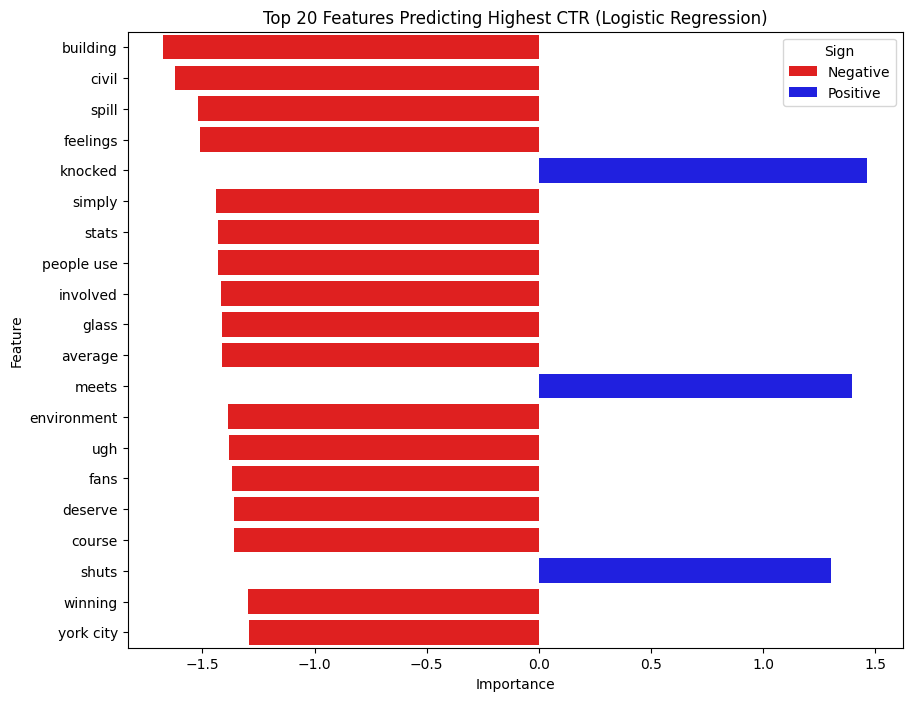

Top 10 Features:
         Feature  Importance
635     building   -1.676086
821        civil   -1.620737
4109       spill   -1.521616
1579    feelings   -1.510161
2417     knocked    1.464867
3995      simply   -1.437400
4154       stats   -1.431739
3230  people use   -1.429497
2252    involved   -1.418300
1798       glass   -1.412985


In [ ]:
# Get the best model from the results
best_result = max(results, key=lambda x: x['ROC-AUC'])
best_model = best_result['Model_Obj']
best_model_name = best_result['Model']

print(f"Analyzing Feature Importance for: {best_model_name}")

# Prepare feature names
tfidf_names = tfidf.get_feature_names_out()
all_feature_names = list(tfidf_names) + numeric_features

# Extract importances based on model type
importances = None
if hasattr(best_model, "feature_importances_"): 
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"): 
    importances = best_model.coef_[0]

# Visualize
if importances is not None:
    feat_imp = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feat_imp['Abs_Importance'] = feat_imp['Importance'].abs() 
    top_features = feat_imp.sort_values(by='Abs_Importance', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    
    if best_model_name == "Logistic Regression":
        top_features['Sign'] = top_features['Importance'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
        
        sns.barplot(
            x = 'Importance', 
            y = 'Feature', 
            data = top_features, 
            hue = 'Sign', 
            palette = {'Positive': 'blue', 'Negative': 'red'},
            dodge = False 
        )
    else:
        sns.barplot(
            x = 'Importance', 
            y = 'Feature', 
            data = top_features, 
            hue = 'Feature', 
            palette = 'magma', 
            legend = False
        )

    plt.title(f"Top 20 Features Predicting Highest CTR ({best_model_name})")
    plt.show()
    
    print("Top 10 Features:")
    print(top_features[['Feature', 'Importance']].head(10))
else:
    print("Feature importance not available for this model.")

## 7. Conclusion: The "Semantic Ceiling" of Traditional NLP

### Summary of Experiments
We conducted a rigorous benchmark using state-of-the-art Traditional NLP methods, targeting the **Highest CTR Headline** (`is_highest_ctr`) to remove editorial subjectivity.

### Key Findings
1.  **Marginal Improvement, Yet Insufficient:**
    * Comparing to the previous `winner` prediction (ROC-AUC ~0.50), predicting the objective `highest_ctr` yielded a **slightly better score of ~0.55**.
    * This indicates that while "Click-Through Rate" is objectively easier to predict than "Editorial Taste," **traditional models still fail to achieve meaningful predictive power (AUC > 0.7)**.

2.  **The "Semantic Ceiling":**
    * The fact that even the best model (Logistic Regression) capped at **0.55 AUC** confirms that **keywords and surface-level sentiment are not the primary drivers of virality**.
    * The machine sees "words," but the user clicks on "intrigue."

### Strategic Implication for Phase 2
**"Why do we need LLMs?"**
The persistent failure across both targets (`winner` and `highest_ctr`) proves that the **"Curiosity Gap"** is a deep semantic nuance invisible to statistical feature engineering.

* **Traditional NLP:** Counts words (e.g., "Does 'video' appear?").
* **Generative AI (LLM):** Understands intent (e.g., "Does this headline create a burning question?").

**Therefore, this benchmark provides the definitive data-driven justification for our team's transition to GPT-4 based approaches.**